In [87]:
# Downloads
%pip install ftfy

In [162]:
# Imports
import re
import ftfy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split

In [89]:
# Read in fake data
true = pd.read_csv("Fake.csv")
true["outcome"] = "Fake"

# Read in true data
false = pd.read_csv("True.csv")
false["outcome"] = "True"

# Concatenate them together
all_data = pd.concat([true, false])
all_data = all.sample(frac = 1, random_state = 1).reset_index(drop = True)

all_data.head()

,title,text,subject,date,outcome
0,FARMER FINED A WHOPPING $2.8 MILLION Asks Pres...,A California farmer fined $2.8 million for plo...,Government News,"Jul 29, 2017",Fake
1,Campaigning in style: How Jeb Bush blew throug...,NEW YORK (Reuters) - There were stays at bouti...,politicsNews,"January 28, 2016",True
2,Syria rejects report blaming it for April sari...,BEIRUT (Reuters) - The Syrian government rejec...,worldnews,"October 27, 2017",True
3,WATCH: CNN Analyst Calls Trump A ‘Son Of A Bit...,Donald Trump s destructive vision of America i...,News,"December 2, 2016",Fake
4,Trump’s Latest Tease Pales Next to Bush and Go...,It s teetering on the ridiculous watching the ...,Middle-east,"October 24, 2016",Fake


In [90]:
# Get some information about the data
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   outcome  44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB


In [91]:
# Strip whitespace for the text columns
all_data["title"] = all_data["title"].str.strip()
all_data["text"] = all_data["text"].str.strip()
all_data["subject"] = all_data["subject"].str.strip()
all_data["date"] = all_data["date"].str.strip()

all_data.head()

,title,text,subject,date,outcome
0,FARMER FINED A WHOPPING $2.8 MILLION Asks Pres...,A California farmer fined $2.8 million for plo...,Government News,"Jul 29, 2017",Fake
1,Campaigning in style: How Jeb Bush blew throug...,NEW YORK (Reuters) - There were stays at bouti...,politicsNews,"January 28, 2016",True
2,Syria rejects report blaming it for April sari...,BEIRUT (Reuters) - The Syrian government rejec...,worldnews,"October 27, 2017",True
3,WATCH: CNN Analyst Calls Trump A ‘Son Of A Bit...,Donald Trump s destructive vision of America i...,News,"December 2, 2016",Fake
4,Trump’s Latest Tease Pales Next to Bush and Go...,It s teetering on the ridiculous watching the ...,Middle-east,"October 24, 2016",Fake


In [92]:
# Convert our dates to datetime
dates = pd.to_datetime(all_data["date"], format = "mixed", errors  = "coerce")

# Find places with errors
all_data.loc[dates.isnull()]

,title,text,subject,date,outcome
3068,https://100percentfedup.com/served-roy-moore-v...,https://100percentfedup.com/served-roy-moore-v...,politics,https://100percentfedup.com/served-roy-moore-v...,Fake
5609,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,left-news,https://fedup.wpengine.com/wp-content/uploads/...,Fake
6948,https://100percentfedup.com/video-hillary-aske...,https://100percentfedup.com/video-hillary-aske...,politics,https://100percentfedup.com/video-hillary-aske...,Fake
11125,https://100percentfedup.com/12-yr-old-black-co...,https://100percentfedup.com/12-yr-old-black-co...,politics,https://100percentfedup.com/12-yr-old-black-co...,Fake
12438,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,politics,https://fedup.wpengine.com/wp-content/uploads/...,Fake
21454,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,politics,https://fedup.wpengine.com/wp-content/uploads/...,Fake
25199,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,Government News,https://fedup.wpengine.com/wp-content/uploads/...,Fake
30559,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,Government News,https://fedup.wpengine.com/wp-content/uploads/...,Fake
43889,Homepage,[vc_row][vc_column width= 1/1 ][td_block_trend...,left-news,MSNBC HOST Rudely Assumes Steel Worker Would N...,Fake
44006,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,left-news,https://fedup.wpengine.com/wp-content/uploads/...,Fake


In [93]:
# Find the distribution of errors between outcomes
all_data.loc[dates.isnull()]["outcome"].value_counts()

,count
outcome,
Fake,10


In [95]:
# Convert them in the dataframe
all_data["date"] = dates

# Delete the bad ones
all_data = all_data.loc[~all_data["date"].isnull()]

all_data.head()

,title,text,subject,date,outcome
0,FARMER FINED A WHOPPING $2.8 MILLION Asks Pres...,A California farmer fined $2.8 million for plo...,Government News,2017-07-29,Fake
1,Campaigning in style: How Jeb Bush blew throug...,NEW YORK (Reuters) - There were stays at bouti...,politicsNews,2016-01-28,True
2,Syria rejects report blaming it for April sari...,BEIRUT (Reuters) - The Syrian government rejec...,worldnews,2017-10-27,True
3,WATCH: CNN Analyst Calls Trump A ‘Son Of A Bit...,Donald Trump s destructive vision of America i...,News,2016-12-02,Fake
4,Trump’s Latest Tease Pales Next to Bush and Go...,It s teetering on the ridiculous watching the ...,Middle-east,2016-10-24,Fake


In [96]:
# URL pattern
url_pattern = r"https?://\S+|www\.\S+"

# Method to determine how much of a given string is made up of links
def get_link_ratio(text):
    # Find all occurrences of links
    links = re.findall(url_pattern, text)

    # Get text length
    text_length = 1 if len(text) == 0 else len(text)

    # Return the ratio
    return sum([len(link) for link in links]) / text_length

# Find the places where a link makes up most of the title or text
all_data[(all_data["title"].apply(get_link_ratio) >= 0.5) | (all_data["text"].apply(get_link_ratio) >= 0.5)]

,title,text,subject,date,outcome
1911,MELANIA TRUMP GIVES POWERFUL SPEECH to Honor ‘...,https://www.youtube.com/watch?v=cJZFepSvxzM,politics,2017-03-30,Fake
2340,KELLYANNE CONWAY On Trump’s Terrorism Policy: ...,https://www.youtube.com/watch?v=0cVugq2GbBk,politics,2016-12-23,Fake
2590,TERRORISM EXPERT SEBASTIAN GORKA On What Next ...,https://www.youtube.com/watch?v=-7Tn4gi_Os8,politics,2017-03-26,Fake
2924,UNREAL! CNN PANEL Laughs And Mocks Dr. Ben Car...,https://www.youtube.com/watch?v=_FNt3ns_EGA,politics,2016-12-06,Fake
3418,FULL INTERVIEW: PRESIDENT TRUMP Nails It On Im...,https://www.youtube.com/watch?v=hNPX8ZCIfc0&t=26s,left-news,2017-02-28,Fake
...,...,...,...,...,...
43031,TUCKER CARLSON DESTROYS Smug Elector Who Refus...,https://youtu.be/7oOhwHG2Gb4,politics,2016-12-09,Fake
43352,WATCH Huge Crowd Of Muslims Admit That ALL Mus...,https://www.youtube.com/watch?v=8Mehk5eWcZA,left-news,2017-02-08,Fake
44119,WATCH KELLYANNE CONWAY vs Total Jerk Chris Cuo...,https://www.youtube.com/watch?v=6VN1maBEKIk,politics,2017-01-07,Fake
44664,JUDGE JEANINE PIRRO’S TRUTH BOMB On Fired US A...,https://www.youtube.com/watch?v=yRXmFmgoPTk,politics,2017-03-12,Fake


In [97]:
# Find the distribution of mostly link data between outcomes
all_data[(all_data["title"].apply(get_link_ratio) >= 0.5) | (all_data["text"].apply(get_link_ratio) >= 0.5)]["outcome"].value_counts()

,count
outcome,
Fake,79


In [98]:
# Delete the places where a link makes up most of the title or text
all_data = all_data[(all_data["title"].apply(get_link_ratio) < 0.5) | (all_data["text"].apply(get_link_ratio) < 0.5)]

all_data.head()

,title,text,subject,date,outcome
0,FARMER FINED A WHOPPING $2.8 MILLION Asks Pres...,A California farmer fined $2.8 million for plo...,Government News,2017-07-29,Fake
1,Campaigning in style: How Jeb Bush blew throug...,NEW YORK (Reuters) - There were stays at bouti...,politicsNews,2016-01-28,True
2,Syria rejects report blaming it for April sari...,BEIRUT (Reuters) - The Syrian government rejec...,worldnews,2017-10-27,True
3,WATCH: CNN Analyst Calls Trump A ‘Son Of A Bit...,Donald Trump s destructive vision of America i...,News,2016-12-02,Fake
4,Trump’s Latest Tease Pales Next to Bush and Go...,It s teetering on the ridiculous watching the ...,Middle-east,2016-10-24,Fake


In [99]:
# Find places where the title and text are the same
all_data[all_data["title"] == all_data["text"]]

,title,text,subject,date,outcome


In [100]:
# Find articles that appear in both datasets
all_data[all_data.groupby(["title", "text"])["outcome"].transform("nunique") == 2]

,title,text,subject,date,outcome


In [101]:
# Find duplicate rows
all_data[all_data.duplicated(subset = ["title", "text"], keep = "first")]

,title,text,subject,date,outcome
209,TOMI LAHREN’S Rant Against Anti-Trump Rioters ...,Share this with every offended snowflake in Am...,politics,2016-11-14,Fake
388,THE VIDEO LIBERALS Don’t Want You To See: LIL ...,"Lil Wayne, whose real name is Dwayne Michael C...",politics,2017-05-14,Fake
423,RECKLESS DEM MAYOR BLAMES AMTRAK ENGINEER FOR ...,Perhaps Democrat Mayor Michael Nutter is takin...,left-news,2015-05-16,Fake
550,Two-thirds of US Navy Strike Fighter Jets Grou...,21st Century Wire says Defense News said that ...,Middle-east,2017-02-12,Fake
889,FAMILY LIVING ‘TRADITIONAL LIFESTYLE’ TORN APA...,Conform or pay the ultimate price Police seize...,left-news,2015-05-09,Fake
...,...,...,...,...,...
44873,JAPANESE SCHOOLS DON’T EMPLOY JANITORS…Why Ame...,Watch NPR employee and Afghanistan refugee (wh...,politics,2017-02-15,Fake
44882,HE WAS WARNED AGAINST NEGOTIATING WITH TERRORI...,"Iran, where the thought police will always hav...",Government News,2015-04-23,Fake
44888,"BREAKING: Democrat Congressman, Vocal ILLEGAL ...","Rep. Luis Guti rrez (Ill.), one of the most vo...",left-news,2017-11-27,Fake
44891,"OBAMA’S RACISM CZAR, “REVEREND” AL SHARPTON CA...",Yeah putting the federal government in charge ...,politics,2015-04-09,Fake


In [102]:
# Find the distribution of duplicated data between outcomes
all_data[all_data.duplicated(subset = ["title", "text"], keep = "first")]["outcome"].value_counts()

,count
outcome,
Fake,5570
True,221


In [103]:
# Remove duplicate data
all_data = all_data.drop_duplicates(subset = ["title", "text"], keep = "first")

all_data.head()

,title,text,subject,date,outcome
0,FARMER FINED A WHOPPING $2.8 MILLION Asks Pres...,A California farmer fined $2.8 million for plo...,Government News,2017-07-29,Fake
1,Campaigning in style: How Jeb Bush blew throug...,NEW YORK (Reuters) - There were stays at bouti...,politicsNews,2016-01-28,True
2,Syria rejects report blaming it for April sari...,BEIRUT (Reuters) - The Syrian government rejec...,worldnews,2017-10-27,True
3,WATCH: CNN Analyst Calls Trump A ‘Son Of A Bit...,Donald Trump s destructive vision of America i...,News,2016-12-02,Fake
4,Trump’s Latest Tease Pales Next to Bush and Go...,It s teetering on the ridiculous watching the ...,Middle-east,2016-10-24,Fake


In [104]:
# Find data with empty title or text
all_data[(all_data["title"] == "") | (all_data["text"] == "")]

,title,text,subject,date,outcome
8,EDUCATION SECRETARY BLOCKED And Harrassed Tryi...,,left-news,2017-02-10,Fake
130,FLASHBACK: PRESIDENT-ELECT DONALD TRUMP Sings ...,,politics,2017-01-07,Fake
305,TRUMP TWEETS CRITICISM OF CHINA: Reminds The W...,,politics,2016-12-04,Fake
306,ALMOST 100 YEARS LATER…Donald Trump Sounds A L...,,left-news,2016-11-19,Fake
327,AWKWARD! CAMERAS CATCH HILLARY Catching Bill C...,,politics,2017-01-20,Fake
...,...,...,...,...,...
44388,FIRST LADY Makes Surprise Visit to Hospital…Vi...,,politics,2017-03-02,Fake
44491,BOOM! TREY GOWDY Shoots Down Outrage Over Inte...,,politics,2017-03-27,Fake
44519,DNC CHAIR Vows To Build Party In All *57* Stat...,,politics,2017-02-28,Fake
44583,A MUST SEE! MEDIA SCORCHED FOR THEIR BIAS AGAI...,,politics,2016-10-04,Fake


In [105]:
# Find the distribution of empty data between outcomes
all_data[(all_data["title"] == "") | (all_data["text"] == "")]["outcome"].value_counts()

,count
outcome,
Fake,446
True,1


In [106]:
# Drop empty data
all_data = all_data[(all_data["title"] != "") & (all_data["text"] != "")]

all_data.head()

,title,text,subject,date,outcome
0,FARMER FINED A WHOPPING $2.8 MILLION Asks Pres...,A California farmer fined $2.8 million for plo...,Government News,2017-07-29,Fake
1,Campaigning in style: How Jeb Bush blew throug...,NEW YORK (Reuters) - There were stays at bouti...,politicsNews,2016-01-28,True
2,Syria rejects report blaming it for April sari...,BEIRUT (Reuters) - The Syrian government rejec...,worldnews,2017-10-27,True
3,WATCH: CNN Analyst Calls Trump A ‘Son Of A Bit...,Donald Trump s destructive vision of America i...,News,2016-12-02,Fake
4,Trump’s Latest Tease Pales Next to Bush and Go...,It s teetering on the ridiculous watching the ...,Middle-east,2016-10-24,Fake


In [107]:
# Fix some of the unicode issues that are present in the data
all_data["title"] = all_data["title"].apply(ftfy.fix_text)
all_data["text"] = all_data["text"].apply(ftfy.fix_text)

all_data.head()

,title,text,subject,date,outcome
0,FARMER FINED A WHOPPING $2.8 MILLION Asks Pres...,A California farmer fined $2.8 million for plo...,Government News,2017-07-29,Fake
1,Campaigning in style: How Jeb Bush blew throug...,NEW YORK (Reuters) - There were stays at bouti...,politicsNews,2016-01-28,True
2,Syria rejects report blaming it for April sari...,BEIRUT (Reuters) - The Syrian government rejec...,worldnews,2017-10-27,True
3,WATCH: CNN Analyst Calls Trump A 'Son Of A Bit...,Donald Trump s destructive vision of America i...,News,2016-12-02,Fake
4,Trump's Latest Tease Pales Next to Bush and Go...,It s teetering on the ridiculous watching the ...,Middle-east,2016-10-24,Fake


In [130]:
# The text column for the True data often has "CITY (Source) - " at the start,
# we want to remove this so the model does not learn this pattern
text_start_pattern = r"^.{0,50}?\([^)]{0,50}\)\s*-\s*"
all_data["text"] = all_data["text"].str.replace(text_start_pattern, "", regex = True)

all_data.head()

,title,text,subject,date,outcome
0,FARMER FINED A WHOPPING $2.8 MILLION Asks Pres...,A California farmer fined $2.8 million for plo...,Government News,2017-07-29,Fake
1,Campaigning in style: How Jeb Bush blew throug...,There were stays at boutique hotels featuring ...,politicsNews,2016-01-28,True
2,Syria rejects report blaming it for April sari...,The Syrian government rejected a report sent t...,worldnews,2017-10-27,True
3,WATCH: CNN Analyst Calls Trump A 'Son Of A Bit...,Donald Trump s destructive vision of America i...,News,2016-12-02,Fake
4,Trump's Latest Tease Pales Next to Bush and Go...,It s teetering on the ridiculous watching the ...,Middle-east,2016-10-24,Fake


In [141]:
# The title column for the Fake data often has " (MEDIA TYPE)" at the end, we
# want to remove this so the model does not learn this pattern
title_end_pattern = r"\s*[\(\[][a-zA-Z\s]{0,15}[\)\]]$"
all_data["title"] = all_data["title"].str.replace(title_end_pattern, "", regex = True)

all_data.head()

,title,text,subject,date,outcome
0,FARMER FINED A WHOPPING $2.8 MILLION Asks Pres...,A California farmer fined $2.8 million for plo...,Government News,2017-07-29,Fake
1,Campaigning in style: How Jeb Bush blew throug...,There were stays at boutique hotels featuring ...,politicsNews,2016-01-28,True
2,Syria rejects report blaming it for April sari...,The Syrian government rejected a report sent t...,worldnews,2017-10-27,True
3,WATCH: CNN Analyst Calls Trump A 'Son Of A Bit...,Donald Trump s destructive vision of America i...,News,2016-12-02,Fake
4,Trump's Latest Tease Pales Next to Bush and Go...,It s teetering on the ridiculous watching the ...,Middle-east,2016-10-24,Fake


In [166]:
# Combine title and text into one column for encoding purposes
all_data["title_text"] = all_data["title"] + "\n" + all_data["text"]
all_data = all_data.drop(columns = ["title", "text"])

all_data

,subject,date,outcome,title_text
0,Government News,2017-07-29,Fake,FARMER FINED A WHOPPING $2.8 MILLION Asks Pres...
1,politicsNews,2016-01-28,True,Campaigning in style: How Jeb Bush blew throug...
2,worldnews,2017-10-27,True,Syria rejects report blaming it for April sari...
3,News,2016-12-02,Fake,WATCH: CNN Analyst Calls Trump A 'Son Of A Bit...
4,Middle-east,2016-10-24,Fake,Trump's Latest Tease Pales Next to Bush and Go...
...,...,...,...,...
44893,politicsNews,2017-05-22,True,"In U.S. presidential first, Trump prays at Jer..."
44894,worldnews,2017-12-08,True,"Iranians rally against Trump's Jerusalem move,..."
44895,News,2017-03-15,Fake,Conservatives Are Now Threatening The Family O...
44896,worldnews,2017-11-28,True,New Venezuela oil chief vows anti-corruption c...


In [171]:
# Get some information about the data
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38650 entries, 0 to 44897
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   subject     38650 non-null  object        
 1   date        38650 non-null  datetime64[ns]
 2   outcome     38650 non-null  object        
 3   title_text  38650 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 2.5+ MB


In [172]:
# What is the distribution of outcomes?
all_data["outcome"].value_counts()

,count
outcome,
True,21195
Fake,17455


In [173]:
# What is the distribution of subjects?
grouped = all_data.groupby(["outcome", "subject"]).size().reset_index()
grouped["outcome_total"] = grouped.groupby("outcome")[0].transform("sum")
grouped.sort_values(by = ["outcome_total", 0], ascending = [False, False]).drop(columns = ["outcome_total"])

,outcome,subject,0
6,True,politicsNews,11208
7,True,worldnews,9987
2,Fake,News,9050
5,Fake,politics,4332
4,Fake,left-news,2388
0,Fake,Government News,902
3,Fake,US_News,397
1,Fake,Middle-east,386


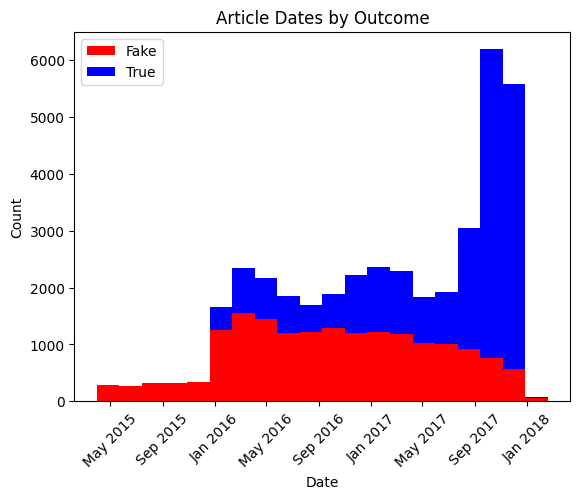

In [174]:
# Split data into categories
fake_data = all_data[all_data["outcome"] == "Fake"]["date"]
true_data = all_data[all_data["outcome"] == "True"]["date"]

# Plot a histogram
plt.hist([fake_data, true_data], bins = 20, stacked = True, label = ["Fake", "True"], color = ["r", "b"])

# Format dates
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Format plot
plt.title("Article Dates by Outcome")
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.legend()

In [176]:
# We now remove the subject and date columns as we just want to train on text
all_data = all_data.drop(columns = ["subject", "date"])

all_data.head()

KeyError: "['subject', 'date'] not found in axis"

In [178]:
# What is x and what is y?
x = "title_text"
y = "outcome"

In [180]:
# Do a stratified train/val/test split
x_train_val, x_test, y_train_val, y_test = train_test_split(all_data[x], all_data[y], test_size = 1 / 10, random_state = 1, shuffle = True, stratify = all_data[y])
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size = 1 / 9, random_state = 1, shuffle = True, stratify = y_train_val)